#  GAN

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

__Выполнила Ларькова Дарья__

Материалы:
* https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html
* https://www.kaggle.com/datasets/splcher/animefacedataset
* https://github.com/eriklindernoren/PyTorch-GAN

## Задачи для совместного разбора

1\. Обсудите основные шаги в обучении GAN.

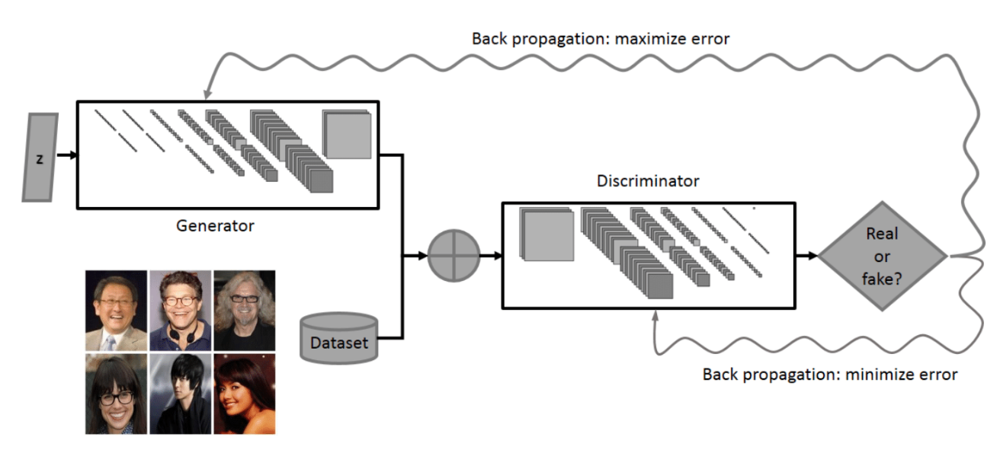

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

## 1\. Создайте набор данных на основе датасета `animefacedataset`. Используя преобразования `torchvision`, приведите изображения к одному размеру и нормализуйте их. Выведите на экран несколько примеров изображений.

- [ ] Проверено на семинаре

In [1]:
import importlib.util

if importlib.util.find_spec("torchvision") is None:
    raise ImportError(
        "torchvision не установлен. Установите совместимую с вашей версией PyTorch "
        "версию torchvision и перезапустите kernel."
    )
print("torchvision найден — можно продолжать без переустановки пакетов.")


torchvision найден — можно продолжать без переустановки пакетов.


In [2]:
import argparse
import os
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.optim as optim
import torch.utils.data
import torchvision
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from PIL import Image
from IPython.display import HTML

manualSeed = 999
print("Random Seed:", manualSeed)
print("PyTorch:", torch.__version__)
print("torchvision:", torchvision.__version__)
random.seed(manualSeed)
np.random.seed(manualSeed)
torch.manual_seed(manualSeed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(manualSeed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


Random Seed: 999
PyTorch: 2.13.0+cu130
torchvision: 0.28.0+cu130


In [3]:
import zipfile
from pathlib import Path


In [4]:
zip_path = Path('archive.zip')
extract_path = Path('anime_faces')

if not extract_path.exists():
    if not zip_path.exists():
        raise FileNotFoundError(f"Не найден архив {zip_path.resolve()}")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("🟩 Архив распакован")
else:
    print(f"Датасет уже распакован: {extract_path}")


Датасет уже распакован: anime_faces


In [5]:
dataroot = "anime_faces"
workers = 0
batch_size = 128
image_size = 64
nc = 3
nz = 100
ngf = 64
ndf = 64
num_epochs = 20
lr = 0.0002
beta1 = 0.5
ngpu = 1

Найдено изображений: 63565
Устройство: cuda:0


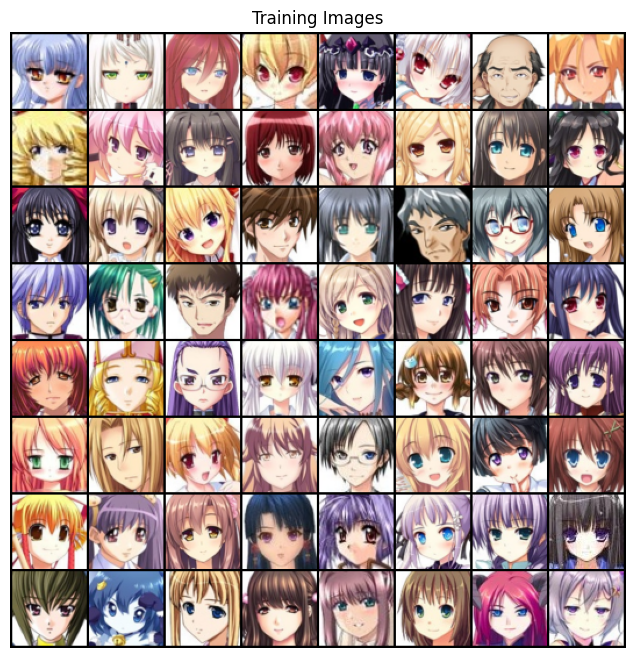

In [6]:
image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
anime_image_paths = sorted(
    p for p in Path(dataroot).rglob('*')
    if p.is_file() and p.suffix.lower() in image_extensions
)

if not anime_image_paths:
    raise FileNotFoundError(
        f"В {Path(dataroot).resolve()} не найдено изображений. "
        "Проверьте archive.zip и структуру распакованного датасета."
    )

anime_transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

class AnimeFacesDataset(torch.utils.data.Dataset):
    def __init__(self, paths, transform=None):
        self.paths = list(paths)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        image = Image.open(self.paths[idx]).convert('RGB')
        if self.transform is not None:
            image = self.transform(image)
        # Метка не используется GAN, но сохраняет интерфейс (image, label).
        return image, 0

dataset = AnimeFacesDataset(anime_image_paths, anime_transform)
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=workers,
    pin_memory=torch.cuda.is_available(),
)

device = torch.device("cuda:0" if (torch.cuda.is_available() and ngpu > 0) else "cpu")
print(f"Найдено изображений: {len(dataset)}")
print(f"Устройство: {device}")

# Несколько примеров после Resize/Crop/Normalize.
real_batch = next(iter(dataloader))
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training Images")
grid = vutils.make_grid(real_batch[0][:64], padding=2, normalize=True)
plt.imshow(np.transpose(grid.cpu(), (1, 2, 0)))
plt.show()


<p class="task" id="2"></p>

## 2\. Реализуйте архитектуру `DCGAN` и обучите модель. Подберите гиперпараметры таким образом, чтобы получаемые изображения стали достаточного качественными (четкими и без существенных дефектов). Во время обучения сохраняйте примеры генерации изображений из случайного шума и сравните, как менялось качество получаемых изображений в процессе обучения.

- [ ] Проверено на семинаре

In [7]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [8]:
class Generator(nn.Module):
    def __init__(self, ngpu):
        super(Generator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            nn.ConvTranspose2d( nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d( ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d( ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            nn.ConvTranspose2d( ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

In [9]:
netG = Generator(ngpu).to(device)
if (device.type == 'cuda') and (ngpu > 1):
    netG = nn.DataParallel(netG, list(range(ngpu)))
netG.apply(weights_init)
print(netG)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding

In [10]:
class Discriminator(nn.Module):
    def __init__(self, ngpu):
        super(Discriminator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)

In [11]:
netD = Discriminator(ngpu).to(device)
if (device.type == 'cuda') and (ngpu > 1):
    netD = nn.DataParallel(netD, list(range(ngpu)))
netD.apply(weights_init)
print(netD)

Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )

In [12]:
criterion = nn.BCELoss()
fixed_noise = torch.randn(64, nz, 1, 1, device=device)
real_label = 1.
fake_label = 0.
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

In [13]:
img_list = []
G_losses = []
D_losses = []
iters = 0

print("Starting Training Loop...")
for epoch in range(num_epochs):
    for i, data in enumerate(dataloader, 0):
        netD.zero_grad()
        real_cpu = data[0].to(device)
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)
        output = netD(real_cpu).view(-1)
        errD_real = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()
        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(fake_label)
        output = netD(fake.detach()).view(-1)
        errD_fake = criterion(output, label)
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        errD = errD_real + errD_fake
        optimizerD.step()

        netG.zero_grad()
        label.fill_(real_label)  
        output = netD(fake).view(-1)
        errG = criterion(output, label)
        errG.backward()
        D_G_z2 = output.mean().item()
        optimizerG.step()

        if i % 50 == 0:
            print('[%d/%d][%d/%d]\tLoss_D: %.4f\tLoss_G: %.4f\tD(x): %.4f\tD(G(z)): %.4f / %.4f'
                  % (epoch, num_epochs, i, len(dataloader),
                     errD.item(), errG.item(), D_x, D_G_z1, D_G_z2))

        G_losses.append(errG.item())
        D_losses.append(errD.item())

        if (iters % 500 == 0) or ((epoch == num_epochs-1) and (i == len(dataloader)-1)):
            with torch.no_grad():
                fake = netG(fixed_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake, padding=2, normalize=True))

        iters += 1

Starting Training Loop...
[0/20][0/497]	Loss_D: 1.8716	Loss_G: 6.0231	D(x): 0.7587	D(G(z)): 0.7271 / 0.0039
[0/20][50/497]	Loss_D: 0.0108	Loss_G: 35.6250	D(x): 0.9923	D(G(z)): 0.0000 / 0.0000
[0/20][100/497]	Loss_D: 0.7920	Loss_G: 7.5259	D(x): 0.8363	D(G(z)): 0.3375 / 0.0019
[0/20][150/497]	Loss_D: 1.3112	Loss_G: 10.1345	D(x): 0.5083	D(G(z)): 0.0008 / 0.0002
[0/20][200/497]	Loss_D: 0.2898	Loss_G: 7.2760	D(x): 0.8863	D(G(z)): 0.0538 / 0.0035
[0/20][250/497]	Loss_D: 0.5905	Loss_G: 4.2421	D(x): 0.7336	D(G(z)): 0.0994 / 0.0277
[0/20][300/497]	Loss_D: 0.4888	Loss_G: 4.0565	D(x): 0.8511	D(G(z)): 0.2058 / 0.0331
[0/20][350/497]	Loss_D: 0.4116	Loss_G: 7.3429	D(x): 0.9277	D(G(z)): 0.2359 / 0.0011
[0/20][400/497]	Loss_D: 0.4866	Loss_G: 4.9880	D(x): 0.7472	D(G(z)): 0.0440 / 0.0100
[0/20][450/497]	Loss_D: 0.2528	Loss_G: 6.6017	D(x): 0.9050	D(G(z)): 0.0974 / 0.0031
[1/20][0/497]	Loss_D: 1.3259	Loss_G: 4.6002	D(x): 0.4173	D(G(z)): 0.0041 / 0.0205
[1/20][50/497]	Loss_D: 0.8742	Loss_G: 7.5326	D(x): 0.

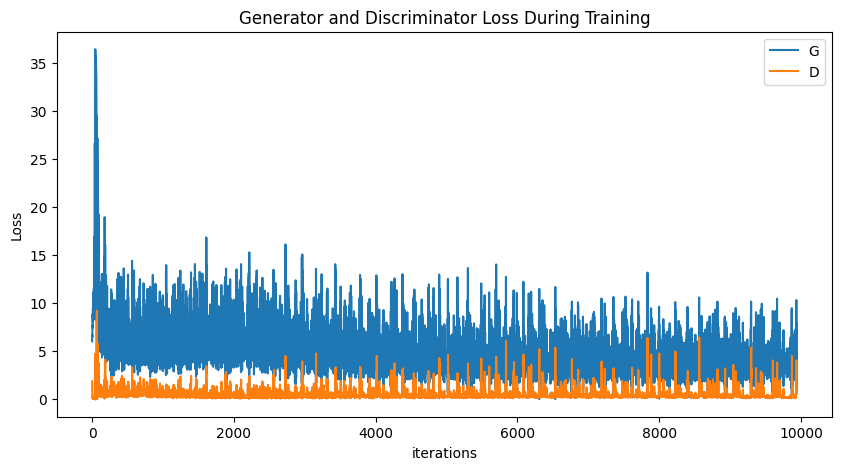

In [14]:
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses,label="G")
plt.plot(D_losses,label="D")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

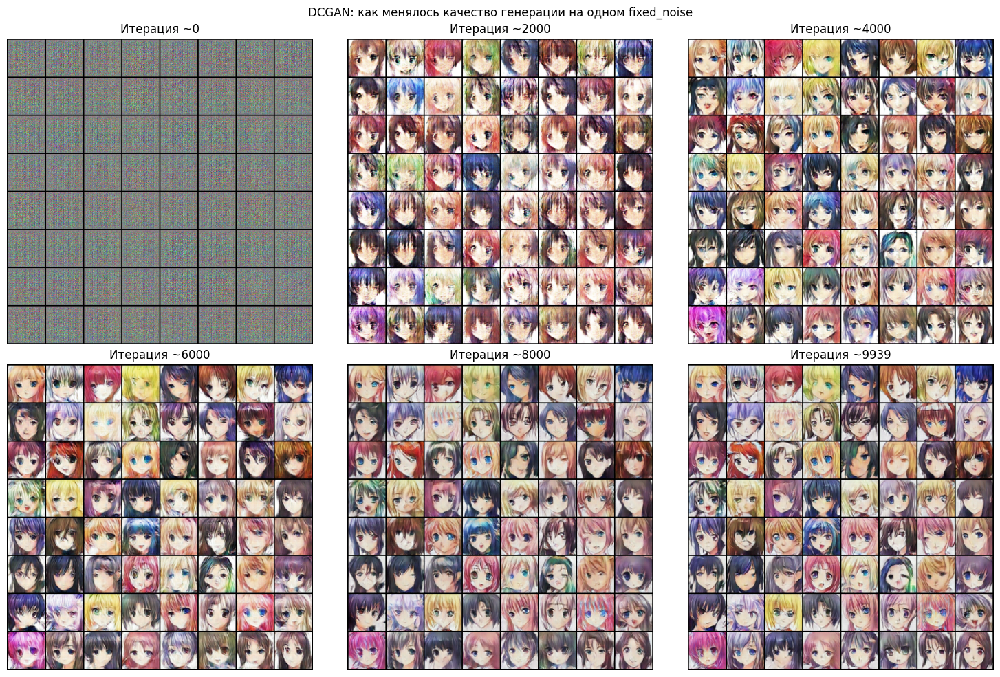

In [15]:
# Сравнение качества генерации DCGAN в процессе обучения.
if not img_list:
    raise RuntimeError("Нет сохранённых генераций.")

n_panels = min(6, len(img_list))
selected_idx = np.unique(np.linspace(0, len(img_list) - 1, n_panels, dtype=int))

cols = 3
rows = int(np.ceil(len(selected_idx) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows), squeeze=False)
axes = axes.ravel()

for ax, idx in zip(axes, selected_idx):
    grid = img_list[idx]
    if torch.is_tensor(grid):
        grid = grid.permute(1, 2, 0).numpy()
    else:
        grid = np.transpose(grid, (1, 2, 0))
    approx_iter = min(idx * 500, max(iters - 1, 0))
    ax.imshow(grid)
    ax.set_title(f"Итерация ~{approx_iter}")
    ax.axis("off")

for ax in axes[len(selected_idx):]:
    ax.axis("off")

fig.suptitle("DCGAN: как менялось качество генерации на одном fixed_noise")
plt.tight_layout()
plt.savefig("dcgan_progression.png", dpi=140, bbox_inches="tight")
plt.show()


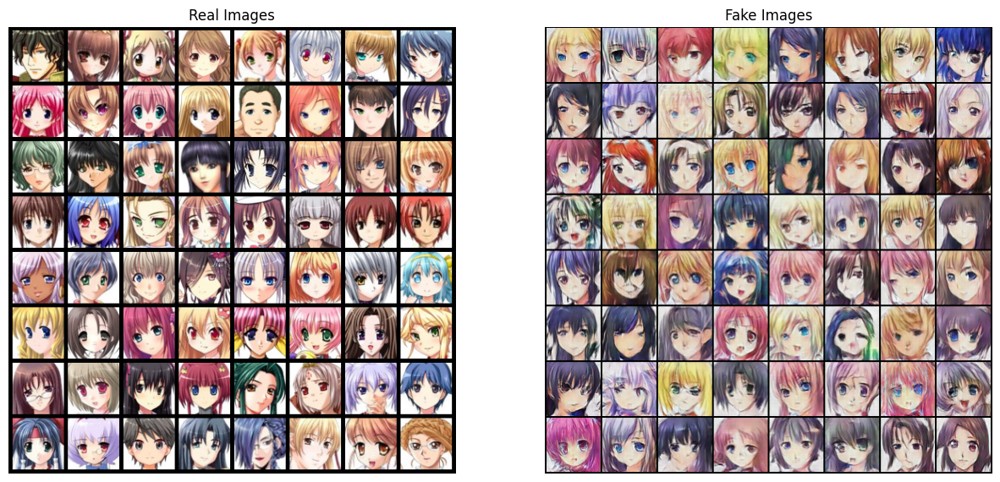

In [16]:
real_batch = next(iter(dataloader))

plt.figure(figsize=(15,15))
plt.subplot(1,2,1)
plt.axis("off")
plt.title("Real Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:64], padding=5, normalize=True).cpu(),(1,2,0)))

plt.subplot(1,2,2)
plt.axis("off")
plt.title("Fake Images")
plt.imshow(np.transpose(img_list[-1],(1,2,0)))
plt.show()

<p class="task" id="3"></p>

## 3\. Создайте наборы данных на основе архива `summer2winter_yosemite.zip`. Используя преобразования `torchvision`, приведите изображения к одному размеру и нормализуйте их. Выведите на экран несколько примеров изображений, расположив изображения из одной пары рядом по горизонтали.

- [ ] Проверено на семинаре

In [17]:
import zipfile
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image


Домен A (лето): summer2winter_yosemite/train/A — 1231 изображений
Домен B (зима): summer2winter_yosemite/train/B — 962 изображений
Размер датасета: 1231


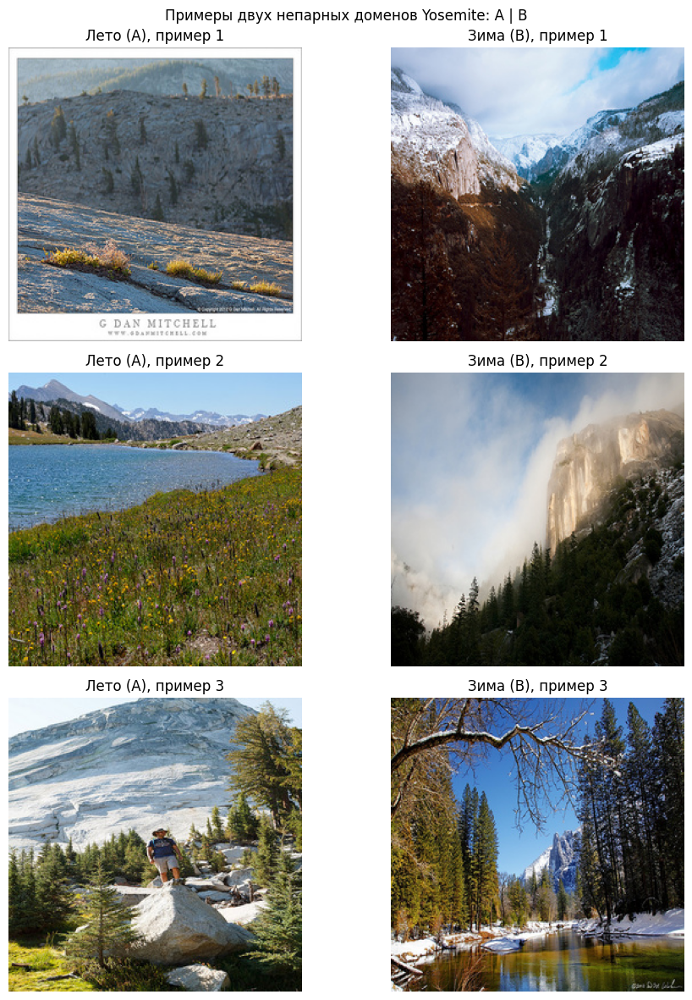

batch A: (8, 3, 256, 256) range=[-1.000, 1.000]
batch B: (8, 3, 256, 256) range=[-1.000, 1.000]


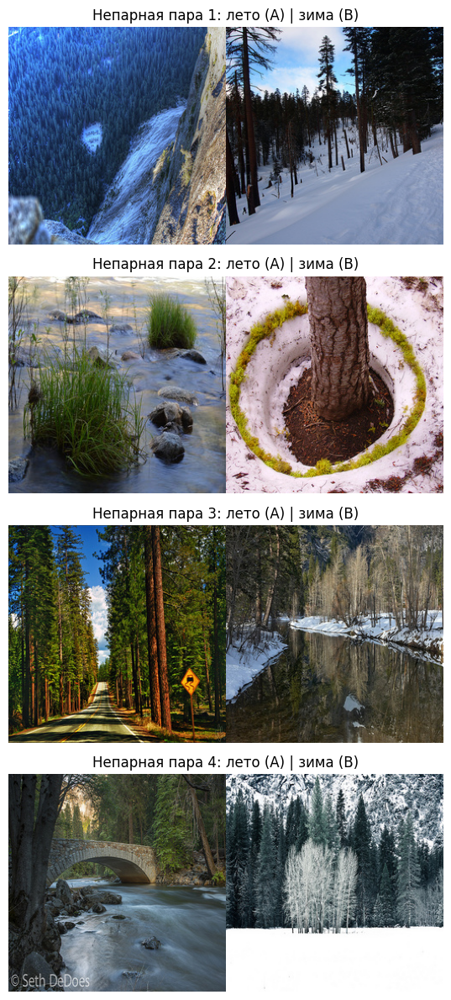

Готово: данные подготовлены как два непарных домена CycleGAN.


In [18]:
zip_path = Path('summer2winter_yosemite.zip')
extract_path = Path('summer2winter_yosemite')
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

if not extract_path.exists():
    if not zip_path.exists():
        raise FileNotFoundError(f"Не найден архив {zip_path.resolve()}")
    print("Распаковка архива...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('.')
    print("Архив распакован.")


def _contains_images(folder):
    folder = Path(folder)
    return folder.is_dir() and any(
        p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS for p in folder.iterdir()
    )


def find_domain_folders(base_path):
    """Находит trainA/trainB (или эквивалентные A/B) для Yosemite."""
    base = Path(base_path)
    candidates = [
        (base / 'trainA', base / 'trainB'),
        (base / 'train' / 'A', base / 'train' / 'B'),
        (base / 'A', base / 'B'),
        (base / 'summer', base / 'winter'),
    ]
    for a, b in candidates:
        if _contains_images(a) and _contains_images(b):
            return a, b

    for a in base.rglob('trainA'):
        b = a.parent / 'trainB'
        if _contains_images(a) and _contains_images(b):
            return a, b
    for a in base.rglob('A'):
        b = a.parent / 'B'
        if _contains_images(a) and _contains_images(b):
            return a, b

    raise FileNotFoundError(
        f"Не удалось найти два домена в {base.resolve()}. "
        "Ожидались trainA/trainB, train/A+train/B или A/B."
    )


def list_images(folder):
    return sorted(
        p for p in Path(folder).iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )


domain_a_path, domain_b_path = find_domain_folders(extract_path)
files_a = list_images(domain_a_path)
files_b = list_images(domain_b_path)
print(f"Домен A (лето): {domain_a_path} — {len(files_a)} изображений")
print(f"Домен B (зима): {domain_b_path} — {len(files_b)} изображений")

# CycleGAN обучается на НЕПАРНЫХ данных. Пара (A, B) здесь нужна только для удобной совместной выдачи и визуализации, а не означает одно и то же место.
image_size = (256, 256)
yosemite_transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])


class YosemiteUnpairedDataset(Dataset):
    def __init__(self, folder_a, folder_b, transform=None, random_pair=False):
        self.files_a = list_images(folder_a)
        self.files_b = list_images(folder_b)
        if not self.files_a or not self.files_b:
            raise ValueError("Оба домена должны содержать хотя бы одно изображение")
        self.transform = transform
        self.random_pair = random_pair

    def __len__(self):
        return max(len(self.files_a), len(self.files_b))

    def _load(self, path):
        with Image.open(path) as source:
            img = source.convert('RGB')
        return self.transform(img) if self.transform is not None else img

    def __getitem__(self, idx):
        path_a = self.files_a[idx % len(self.files_a)]
        if self.random_pair:
            path_b = self.files_b[random.randrange(len(self.files_b))]
        else:
            path_b = self.files_b[idx % len(self.files_b)]
        return self._load(path_a), self._load(path_b), path_a.name, path_b.name


dataset = YosemiteUnpairedDataset(
    domain_a_path, domain_b_path,
    transform=yosemite_transform,
    random_pair=False,
)
print(f"Размер датасета: {len(dataset)}")


def denormalize(tensor):
    return (tensor * 0.5 + 0.5).clamp(0, 1)


def show_paired_samples(dataset, num_samples=3):
    """Показывает по одному изображению из домена A и B в каждой строке."""
    n = min(num_samples, len(dataset))
    indices = random.sample(range(len(dataset)), n)
    fig, axes = plt.subplots(n, 2, figsize=(10, 4 * n), squeeze=False)

    for row, idx in enumerate(indices):
        img_a, img_b, name_a, name_b = dataset[idx]
        axes[row, 0].imshow(denormalize(img_a).permute(1, 2, 0).numpy())
        axes[row, 0].set_title(f"Лето (A), пример {row + 1}")
        axes[row, 0].axis('off')

        axes[row, 1].imshow(denormalize(img_b).permute(1, 2, 0).numpy())
        axes[row, 1].set_title(f"Зима (B), пример {row + 1}")
        axes[row, 1].axis('off')

    plt.suptitle("Примеры двух непарных доменов Yosemite: A | B")
    plt.tight_layout()
    plt.show()


show_paired_samples(dataset, num_samples=3)

# DataLoader для проверки размерностей и диапазона после нормализации.
batch_size = 8
dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

batch_a, batch_b, names_a, names_b = next(iter(dataloader))
print("batch A:", tuple(batch_a.shape), f"range=[{batch_a.min():.3f}, {batch_a.max():.3f}]")
print("batch B:", tuple(batch_b.shape), f"range=[{batch_b.min():.3f}, {batch_b.max():.3f}]")

# Отображаем несколько A/B бок о бок по горизонтали.
n_show = min(4, batch_a.size(0))
fig, axes = plt.subplots(n_show, 1, figsize=(10, 3 * n_show), squeeze=False)
for i in range(n_show):
    combined = torch.cat([denormalize(batch_a[i]), denormalize(batch_b[i])], dim=2)
    axes[i, 0].imshow(combined.permute(1, 2, 0).numpy())
    axes[i, 0].set_title(f"Непарная пара {i + 1}: лето (A) | зима (B)")
    axes[i, 0].axis('off')
plt.tight_layout()
plt.show()


def load_yosemite_dataset(zip_path='summer2winter_yosemite.zip',
                          image_size=(256, 256), batch_size=8,
                          random_pair=True):
    """Удобная повторная загрузка двух непарных доменов Yosemite."""
    base = Path('summer2winter_yosemite')
    archive = Path(zip_path)
    if not base.exists():
        if not archive.exists():
            raise FileNotFoundError(f"Не найден {archive.resolve()}")
        with zipfile.ZipFile(archive, 'r') as zip_ref:
            zip_ref.extractall('.')

    folder_a, folder_b = find_domain_folders(base)
    tfm = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])
    ds = YosemiteUnpairedDataset(folder_a, folder_b, tfm, random_pair=random_pair)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=0)
    return loader, ds, False

print("Готово: данные подготовлены как два непарных домена CycleGAN.")


<p class="task" id="4"></p>

## 4\. Реализуйте архитектуру `CycleGAN` и обучите модель. Подберите гиперпараметры таким образом, чтобы получаемые изображения стали достаточного качественными (четкими и без существенных дефектов). Во время обучения сохраняйте примеры преобразования (в обе стороны) и  сравните, как менялось качество получаемых изображений в процессе обучения.

- [ ] Проверено на семинаре

Устройство: cuda
Параметры CycleGAN:
  image_size: 256
  load_size: 286
  batch_size: 1
  epochs: 200
  constant_lr_epochs: 100
  lr: 0.0002
  lambda_cycle: 10.0
  lambda_identity: 2.5
  num_resnet: 9
  ngf: 64
  ndf: 64
  pool_size: 50
  save_every: 10
  seed: 999

Домен A (summer): 1231 изображений
Домен B (winter): 962 изображений
Итераций на эпоху: 1231
Проверка архитектуры: G -> (1, 3, 256, 256), D -> (1, 1, 30, 30)

Начало обучения CycleGAN...
Epoch   1/200 | batch    0/1231 | G=13.886 D=4.019 cycle=0.667 id=0.658
Epoch   1/200 | batch  250/1231 | G=4.777 D=0.278 cycle=0.366 id=0.357
Epoch   1/200 | batch  500/1231 | G=2.915 D=0.230 cycle=0.206 id=0.192
Epoch   1/200 | batch  750/1231 | G=3.244 D=0.248 cycle=0.245 id=0.228
Epoch   1/200 | batch 1000/1231 | G=3.218 D=0.280 cycle=0.230 id=0.205
Epoch   1: G=3.627, D=0.322, Cycle=0.263, Identity=0.242, lr=0.000200
  Сохранён фиксированный preview для эпохи 1.
Epoch   2/200 | batch    0/1231 | G=2.762 D=0.338 cycle=0.187 id=0.151
Epo

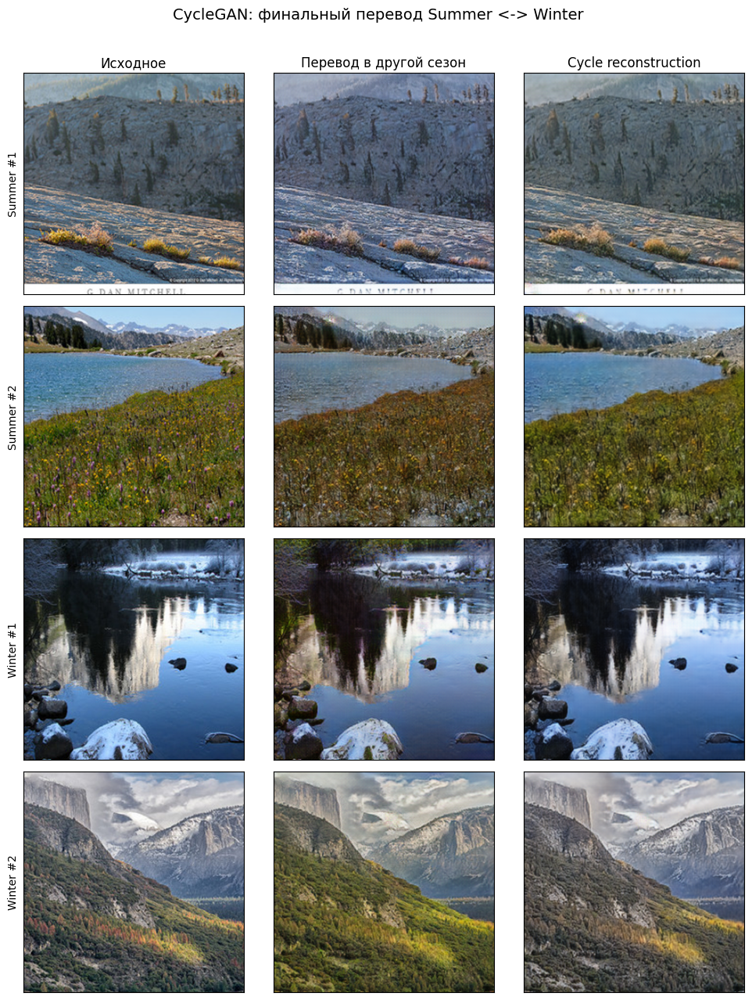

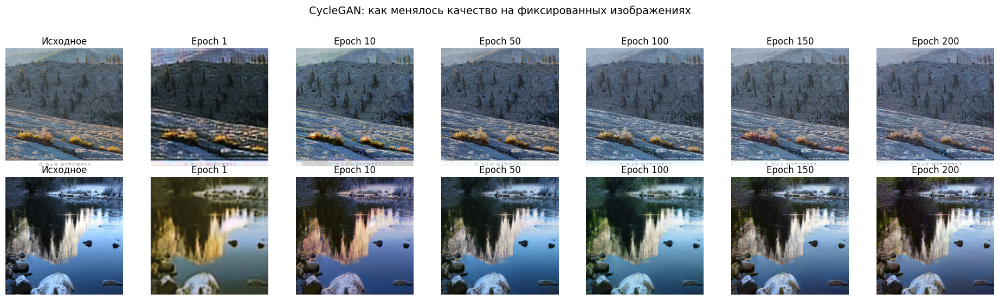

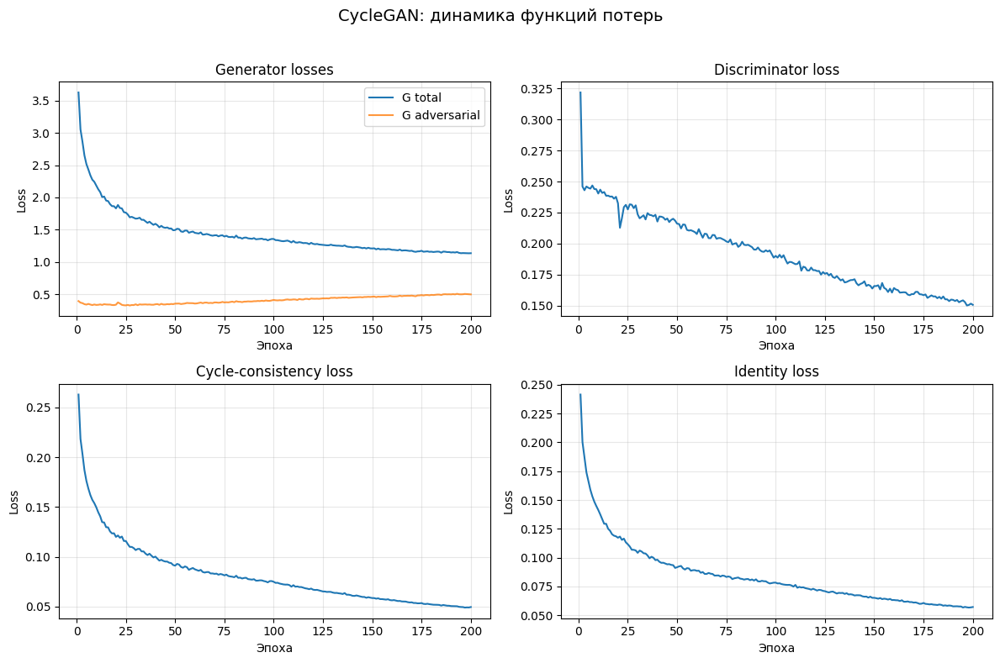


Обучение завершено. Время текущего запуска: 243.9 мин
Результаты сохранены в: /home/crazy/work/labs/cyclegan_results
  - final_gallery.png
  - progression.png
  - losses.png
  - final_weights.pth
  - latest_checkpoint.pth


In [19]:
import os
import json
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image


RESULT_DIR = Path('cyclegan_results')
RESULT_DIR.mkdir(exist_ok=True)

PARAMS = {
    'image_size': 256,
    'load_size': 286,
    'batch_size': 1,
    'epochs': 200,
    'constant_lr_epochs': 100,
    'lr': 2e-4,
    'lambda_cycle': 10.0,
    # Чуть слабее стандартного identity-регуляризатора: для Summer<->Winter это позволяет заметнее менять сезон, не разрушая геометрию сцены.
    'lambda_identity': 2.5,
    'num_resnet': 9,
    'ngf': 64,
    'ndf': 64,
    'pool_size': 50,
    'save_every': 10,
    'seed': 999,
}

# Эпохи, на которых сохраняются изображения одного и того же примера.
PROGRESS_EPOCHS = {1, 10, 25, 50, 75, 100, 125, 150, 175, 200}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {device}')
print('Параметры CycleGAN:')
for key, value in PARAMS.items():
    print(f'  {key}: {value}')

if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True

random.seed(PARAMS['seed'])
np.random.seed(PARAMS['seed'])
torch.manual_seed(PARAMS['seed'])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(PARAMS['seed'])

if 'domain_a_path' not in globals() or 'domain_b_path' not in globals():
    base = Path('summer2winter_yosemite')
    domain_a_path, domain_b_path = find_domain_folders(base)



class CycleGANDataset(Dataset):
    """Непарный датасет CycleGAN: B выбирается независимо от A."""
    def __init__(self, folder_a, folder_b):
        self.files_a = list_images(folder_a)
        self.files_b = list_images(folder_b)
        if not self.files_a or not self.files_b:
            raise ValueError('Оба домена CycleGAN должны содержать изображения')

        self.transform = transforms.Compose([
            transforms.Resize(PARAMS['load_size'], interpolation=transforms.InterpolationMode.BICUBIC),
            transforms.RandomCrop(PARAMS['image_size']),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ])

    def __len__(self):
        return max(len(self.files_a), len(self.files_b))

    def _load(self, path):
        with Image.open(path) as source:
            image = source.convert('RGB')
        return self.transform(image)

    def __getitem__(self, idx):
        path_a = self.files_a[idx % len(self.files_a)]
        path_b = self.files_b[random.randrange(len(self.files_b))]
        return self._load(path_a), self._load(path_b)


train_dataset = CycleGANDataset(domain_a_path, domain_b_path)
train_loader = DataLoader(
    train_dataset,
    batch_size=PARAMS['batch_size'],
    shuffle=True,
    num_workers=0,       # максимально надёжно для Jupyter/Windows/Linux
    pin_memory=(device.type == 'cuda'),
    drop_last=False,
)

print(f'\nДомен A (summer): {len(train_dataset.files_a)} изображений')
print(f'Домен B (winter): {len(train_dataset.files_b)} изображений')
print(f'Итераций на эпоху: {len(train_loader)}')


# Фиксированные изображения НЕ используют случайные crop/flip.
# Благодаря этому на всех эпохах сравнивается один и тот же исходник.
eval_transform = transforms.Compose([
    transforms.Resize(PARAMS['load_size'], interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(PARAMS['image_size']),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])


def load_eval_batch(paths, n=3):
    rng = random.Random(PARAMS['seed'])
    chosen = rng.sample(list(paths), min(n, len(paths)))
    tensors = []
    for path in chosen:
        with Image.open(path) as source:
            image = source.convert('RGB')
        tensors.append(eval_transform(image))
    return torch.stack(tensors).to(device), chosen


fixed_summer, fixed_summer_paths = load_eval_batch(train_dataset.files_a, n=3)
fixed_winter, fixed_winter_paths = load_eval_batch(train_dataset.files_b, n=3)



class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, 3, bias=False),
            nn.InstanceNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, 3, bias=False),
            nn.InstanceNorm2d(channels),
        )

    def forward(self, x):
        return x + self.block(x)


class CycleGenerator(nn.Module):
    """ResNet generator: c7s1-64, d128, d256, R256x9, u128, u64, c7s1-3."""
    def __init__(self, num_resnet=9, ngf=64):
        super().__init__()
        layers = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(3, ngf, 7, bias=False),
            nn.InstanceNorm2d(ngf),
            nn.ReLU(inplace=True),
        ]

        channels = ngf
        for _ in range(2):
            layers += [
                nn.Conv2d(channels, channels * 2, 3, stride=2, padding=1, bias=False),
                nn.InstanceNorm2d(channels * 2),
                nn.ReLU(inplace=True),
            ]
            channels *= 2

        layers += [ResidualBlock(channels) for _ in range(num_resnet)]

        for _ in range(2):
            layers += [
                nn.ConvTranspose2d(
                    channels, channels // 2,
                    kernel_size=3, stride=2, padding=1, output_padding=1,
                    bias=False,
                ),
                nn.InstanceNorm2d(channels // 2),
                nn.ReLU(inplace=True),
            ]
            channels //= 2

        layers += [
            nn.ReflectionPad2d(3),
            nn.Conv2d(channels, 3, 7),
            nn.Tanh(),
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


class PatchDiscriminator(nn.Module):
    """70x70 PatchGAN discriminator."""
    def __init__(self, ndf=64):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, ndf, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 2, 4, stride=2, padding=1, bias=False),
            nn.InstanceNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, ndf * 4, 4, stride=2, padding=1, bias=False),
            nn.InstanceNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 4, ndf * 8, 4, stride=1, padding=1, bias=False),
            nn.InstanceNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 8, 1, 4, stride=1, padding=1),
        )

    def forward(self, x):
        return self.model(x)


class ImagePool:
    """История сгенерированных изображений для стабилизации дискриминатора."""
    def __init__(self, capacity=50):
        self.capacity = int(capacity)
        self.images = []

    def query(self, batch):
        if self.capacity <= 0:
            return batch.detach()

        output = []
        for image in batch.detach():
            image = image.unsqueeze(0)
            if len(self.images) < self.capacity:
                self.images.append(image.cpu())
                output.append(image)
            elif random.random() > 0.5:
                idx = random.randrange(self.capacity)
                old = self.images[idx].to(image.device)
                self.images[idx] = image.cpu()
                output.append(old)
            else:
                output.append(image)
        return torch.cat(output, dim=0)


def init_weights(module):
    if isinstance(module, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(module.weight, 0.0, 0.02)
        if module.bias is not None:
            nn.init.constant_(module.bias, 0.0)


def set_requires_grad(models, value):
    for model in models:
        for parameter in model.parameters():
            parameter.requires_grad_(value)


def tensor_to_image(tensor):
    return (
        (tensor.detach().cpu() * 0.5 + 0.5)
        .clamp(0, 1)
        .permute(1, 2, 0)
        .numpy()
    )


def save_tensor_image(tensor, path):
    image = (tensor_to_image(tensor) * 255.0).round().astype(np.uint8)
    Image.fromarray(image).save(path)


G_summer2winter = CycleGenerator(PARAMS['num_resnet'], PARAMS['ngf']).to(device)
G_winter2summer = CycleGenerator(PARAMS['num_resnet'], PARAMS['ngf']).to(device)
D_summer = PatchDiscriminator(PARAMS['ndf']).to(device)
D_winter = PatchDiscriminator(PARAMS['ndf']).to(device)

for model in (G_summer2winter, G_winter2summer, D_summer, D_winter):
    model.apply(init_weights)

with torch.no_grad():
    probe = torch.zeros(1, 3, PARAMS['image_size'], PARAMS['image_size'], device=device)
    assert G_summer2winter(probe).shape == probe.shape
    assert G_winter2summer(probe).shape == probe.shape
    d_shape = D_summer(probe).shape
    assert len(d_shape) == 4 and d_shape[0] == 1 and d_shape[1] == 1
print(f'Проверка архитектуры: G -> {tuple(probe.shape)}, D -> {tuple(d_shape)}')


criterion_gan = nn.MSELoss()   # LSGAN
criterion_cycle = nn.L1Loss()
criterion_identity = nn.L1Loss()

optimizer_G = optim.Adam(
    list(G_summer2winter.parameters()) + list(G_winter2summer.parameters()),
    lr=PARAMS['lr'], betas=(0.5, 0.999),
)
optimizer_D = optim.Adam(
    list(D_summer.parameters()) + list(D_winter.parameters()),
    lr=PARAMS['lr'], betas=(0.5, 0.999),
)


def lr_lambda(epoch):
    constant = PARAMS['constant_lr_epochs']
    if epoch < constant:
        return 1.0
    decay_length = max(1, PARAMS['epochs'] - constant)
    return max(0.0, 1.0 - (epoch - constant + 1) / decay_length)


scheduler_G = optim.lr_scheduler.LambdaLR(optimizer_G, lr_lambda=lr_lambda)
scheduler_D = optim.lr_scheduler.LambdaLR(optimizer_D, lr_lambda=lr_lambda)

pool_summer = ImagePool(PARAMS['pool_size'])
pool_winter = ImagePool(PARAMS['pool_size'])

losses = {
    'G_total': [], 'G_gan': [], 'D': [],
    'cycle': [], 'identity': [],
}


def save_progress_images(epoch):
    """Сохраняет raw-результаты на одних и тех же изображениях."""
    G_summer2winter.eval()
    G_winter2summer.eval()
    with torch.no_grad():
        fake_winter = G_summer2winter(fixed_summer)
        fake_summer = G_winter2summer(fixed_winter)

    # Для progression достаточно первого фиксированного примера каждого домена.
    save_tensor_image(
        fake_winter[0], RESULT_DIR / f'progress_S2W_{epoch:03d}.png'
    )
    save_tensor_image(
        fake_summer[0], RESULT_DIR / f'progress_W2S_{epoch:03d}.png'
    )

    G_summer2winter.train()
    G_winter2summer.train()


def save_checkpoint(epoch):
    checkpoint = {
        'epoch': int(epoch),
        'G_summer2winter': G_summer2winter.state_dict(),
        'G_winter2summer': G_winter2summer.state_dict(),
        'D_summer': D_summer.state_dict(),
        'D_winter': D_winter.state_dict(),
        'optimizer_G': optimizer_G.state_dict(),
        'optimizer_D': optimizer_D.state_dict(),
        'scheduler_G': scheduler_G.state_dict(),
        'scheduler_D': scheduler_D.state_dict(),
        'losses': losses,
    }
    torch.save(checkpoint, RESULT_DIR / 'latest_checkpoint.pth')


start_epoch = 0
checkpoint_path = RESULT_DIR / 'latest_checkpoint.pth'

# Если обучение было прервано, можно продолжить с последнего checkpoint.
# Новый каталог cyclegan_results не конфликтует со старыми 128x128 весами.
if checkpoint_path.exists():
    try:
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)
    except TypeError:  # PyTorch < 2.6
        checkpoint = torch.load(checkpoint_path, map_location=device)

    G_summer2winter.load_state_dict(checkpoint['G_summer2winter'])
    G_winter2summer.load_state_dict(checkpoint['G_winter2summer'])
    D_summer.load_state_dict(checkpoint['D_summer'])
    D_winter.load_state_dict(checkpoint['D_winter'])
    optimizer_G.load_state_dict(checkpoint['optimizer_G'])
    optimizer_D.load_state_dict(checkpoint['optimizer_D'])
    scheduler_G.load_state_dict(checkpoint['scheduler_G'])
    scheduler_D.load_state_dict(checkpoint['scheduler_D'])
    losses = checkpoint.get('losses', losses)
    start_epoch = int(checkpoint['epoch'])
    print(f'Продолжаем обучение с эпохи {start_epoch + 1}.')

start_time = time.time()
print('\nНачало обучения CycleGAN...')

for epoch in range(start_epoch, PARAMS['epochs']):
    G_summer2winter.train()
    G_winter2summer.train()
    D_summer.train()
    D_winter.train()

    sums = {key: 0.0 for key in losses.keys()}

    for batch_idx, (real_summer, real_winter) in enumerate(train_loader):
        real_summer = real_summer.to(device, non_blocking=True)
        real_winter = real_winter.to(device, non_blocking=True)

        set_requires_grad((D_summer, D_winter), False)
        optimizer_G.zero_grad(set_to_none=True)

        id_winter = G_summer2winter(real_winter)
        id_summer = G_winter2summer(real_summer)
        loss_identity = 0.5 * (
            criterion_identity(id_winter, real_winter) +
            criterion_identity(id_summer, real_summer)
        )

        fake_winter = G_summer2winter(real_summer)
        fake_summer = G_winter2summer(real_winter)

        pred_fake_winter = D_winter(fake_winter)
        pred_fake_summer = D_summer(fake_summer)
        loss_gan = 0.5 * (
            criterion_gan(pred_fake_winter, torch.ones_like(pred_fake_winter)) +
            criterion_gan(pred_fake_summer, torch.ones_like(pred_fake_summer))
        )

        recovered_summer = G_winter2summer(fake_winter)
        recovered_winter = G_summer2winter(fake_summer)
        loss_cycle = 0.5 * (
            criterion_cycle(recovered_summer, real_summer) +
            criterion_cycle(recovered_winter, real_winter)
        )

        loss_G = (
            loss_gan +
            PARAMS['lambda_cycle'] * loss_cycle +
            PARAMS['lambda_identity'] * loss_identity
        )
        loss_G.backward()
        optimizer_G.step()

        set_requires_grad((D_summer, D_winter), True)
        optimizer_D.zero_grad(set_to_none=True)

        pooled_summer = pool_summer.query(fake_summer)
        pooled_winter = pool_winter.query(fake_winter)

        pred_real_summer = D_summer(real_summer)
        pred_fake_summer = D_summer(pooled_summer)
        loss_D_summer = 0.5 * (
            criterion_gan(pred_real_summer, torch.ones_like(pred_real_summer)) +
            criterion_gan(pred_fake_summer, torch.zeros_like(pred_fake_summer))
        )

        pred_real_winter = D_winter(real_winter)
        pred_fake_winter = D_winter(pooled_winter)
        loss_D_winter = 0.5 * (
            criterion_gan(pred_real_winter, torch.ones_like(pred_real_winter)) +
            criterion_gan(pred_fake_winter, torch.zeros_like(pred_fake_winter))
        )

        loss_D = 0.5 * (loss_D_summer + loss_D_winter)
        loss_D.backward()
        optimizer_D.step()

        sums['G_total'] += loss_G.item()
        sums['G_gan'] += loss_gan.item()
        sums['D'] += loss_D.item()
        sums['cycle'] += loss_cycle.item()
        sums['identity'] += loss_identity.item()

        if batch_idx % 250 == 0:
            print(
                f'Epoch {epoch + 1:3d}/{PARAMS["epochs"]} | '
                f'batch {batch_idx:4d}/{len(train_loader)} | '
                f'G={loss_G.item():.3f} D={loss_D.item():.3f} '
                f'cycle={loss_cycle.item():.3f} id={loss_identity.item():.3f}'
            )

    n_batches = len(train_loader)
    for key in losses:
        losses[key].append(sums[key] / n_batches)

    scheduler_G.step()
    scheduler_D.step()

    current_lr = optimizer_G.param_groups[0]['lr']
    print(
        f'Epoch {epoch + 1:3d}: '
        f'G={losses["G_total"][-1]:.3f}, '
        f'D={losses["D"][-1]:.3f}, '
        f'Cycle={losses["cycle"][-1]:.3f}, '
        f'Identity={losses["identity"][-1]:.3f}, '
        f'lr={current_lr:.6f}'
    )

    epoch_number = epoch + 1
    if epoch_number in PROGRESS_EPOCHS:
        save_progress_images(epoch_number)
        print(f'  Сохранён фиксированный preview для эпохи {epoch_number}.')

    if epoch_number % PARAMS['save_every'] == 0 or epoch_number == PARAMS['epochs']:
        save_checkpoint(epoch_number)


G_summer2winter.eval()
G_winter2summer.eval()

with torch.no_grad():
    final_winter = G_summer2winter(fixed_summer)
    final_summer = G_winter2summer(fixed_winter)
    cycle_summer = G_winter2summer(final_winter)
    cycle_winter = G_summer2winter(final_summer)

n_examples = min(2, fixed_summer.size(0), fixed_winter.size(0))
fig, axes = plt.subplots(2 * n_examples, 3, figsize=(10, 3.25 * 2 * n_examples), squeeze=False)

for i in range(n_examples):
    r = i
    axes[r, 0].imshow(tensor_to_image(fixed_summer[i]))
    axes[r, 1].imshow(tensor_to_image(final_winter[i]))
    axes[r, 2].imshow(tensor_to_image(cycle_summer[i]))
    axes[r, 0].set_ylabel(f'Summer #{i + 1}')

    r = n_examples + i
    axes[r, 0].imshow(tensor_to_image(fixed_winter[i]))
    axes[r, 1].imshow(tensor_to_image(final_summer[i]))
    axes[r, 2].imshow(tensor_to_image(cycle_winter[i]))
    axes[r, 0].set_ylabel(f'Winter #{i + 1}')

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

axes[0, 0].set_title('Исходное')
axes[0, 1].set_title('Перевод в другой сезон')
axes[0, 2].set_title('Cycle reconstruction')
fig.suptitle('CycleGAN: финальный перевод Summer <-> Winter', fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.97))
final_gallery_path = RESULT_DIR / 'final_gallery.png'
fig.savefig(final_gallery_path, dpi=160, bbox_inches='tight')
plt.show()


available_epochs = [
    ep for ep in sorted(PROGRESS_EPOCHS)
    if (RESULT_DIR / f'progress_S2W_{ep:03d}.png').exists()
    and (RESULT_DIR / f'progress_W2S_{ep:03d}.png').exists()
]

if len(available_epochs) > 6:
    idx = np.linspace(0, len(available_epochs) - 1, 6, dtype=int)
    shown_epochs = [available_epochs[i] for i in np.unique(idx)]
else:
    shown_epochs = available_epochs

if shown_epochs:
    fig, axes = plt.subplots(2, len(shown_epochs) + 1,
                             figsize=(2.7 * (len(shown_epochs) + 1), 5.6),
                             squeeze=False)

    axes[0, 0].imshow(tensor_to_image(fixed_summer[0]))
    axes[0, 0].set_title('Исходное')
    axes[0, 0].set_ylabel('Summer -> Winter')
    axes[1, 0].imshow(tensor_to_image(fixed_winter[0]))
    axes[1, 0].set_title('Исходное')
    axes[1, 0].set_ylabel('Winter -> Summer')

    for col, ep in enumerate(shown_epochs, start=1):
        axes[0, col].imshow(Image.open(RESULT_DIR / f'progress_S2W_{ep:03d}.png'))
        axes[1, col].imshow(Image.open(RESULT_DIR / f'progress_W2S_{ep:03d}.png'))
        axes[0, col].set_title(f'Epoch {ep}')
        axes[1, col].set_title(f'Epoch {ep}')

    for ax in axes.ravel():
        ax.axis('off')

    fig.suptitle('CycleGAN: как менялось качество на фиксированных изображениях', fontsize=14)
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    progression_path = RESULT_DIR / 'progression.png'
    fig.savefig(progression_path, dpi=160, bbox_inches='tight')
    plt.show()


epoch_axis = np.arange(1, len(losses['G_total']) + 1)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(epoch_axis, losses['G_total'], label='G total')
axes[0, 0].plot(epoch_axis, losses['G_gan'], label='G adversarial', alpha=0.8)
axes[0, 0].set_title('Generator losses')
axes[0, 0].legend()

axes[0, 1].plot(epoch_axis, losses['D'])
axes[0, 1].set_title('Discriminator loss')

axes[1, 0].plot(epoch_axis, losses['cycle'])
axes[1, 0].set_title('Cycle-consistency loss')

axes[1, 1].plot(epoch_axis, losses['identity'])
axes[1, 1].set_title('Identity loss')

for ax in axes.ravel():
    ax.set_xlabel('Эпоха')
    ax.set_ylabel('Loss')
    ax.grid(alpha=0.3)

fig.suptitle('CycleGAN: динамика функций потерь', fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.96))
loss_path = RESULT_DIR / 'losses.png'
fig.savefig(loss_path, dpi=160, bbox_inches='tight')
plt.show()


# Финальные веса генераторов/дискриминаторов в tensor-only checkpoint.
torch.save({
    'G_summer2winter': G_summer2winter.state_dict(),
    'G_winter2summer': G_winter2summer.state_dict(),
    'D_summer': D_summer.state_dict(),
    'D_winter': D_winter.state_dict(),
}, RESULT_DIR / 'final_weights.pth')

with open(RESULT_DIR / 'params.json', 'w', encoding='utf-8') as f:
    json.dump(PARAMS, f, ensure_ascii=False, indent=2)

elapsed = (time.time() - start_time) / 60
print(f'\nОбучение завершено. Время текущего запуска: {elapsed:.1f} мин')
print('Результаты сохранены в:', RESULT_DIR.resolve())
print('  - final_gallery.png')
print('  - progression.png')
print('  - losses.png')
print('  - final_weights.pth')
print('  - latest_checkpoint.pth')


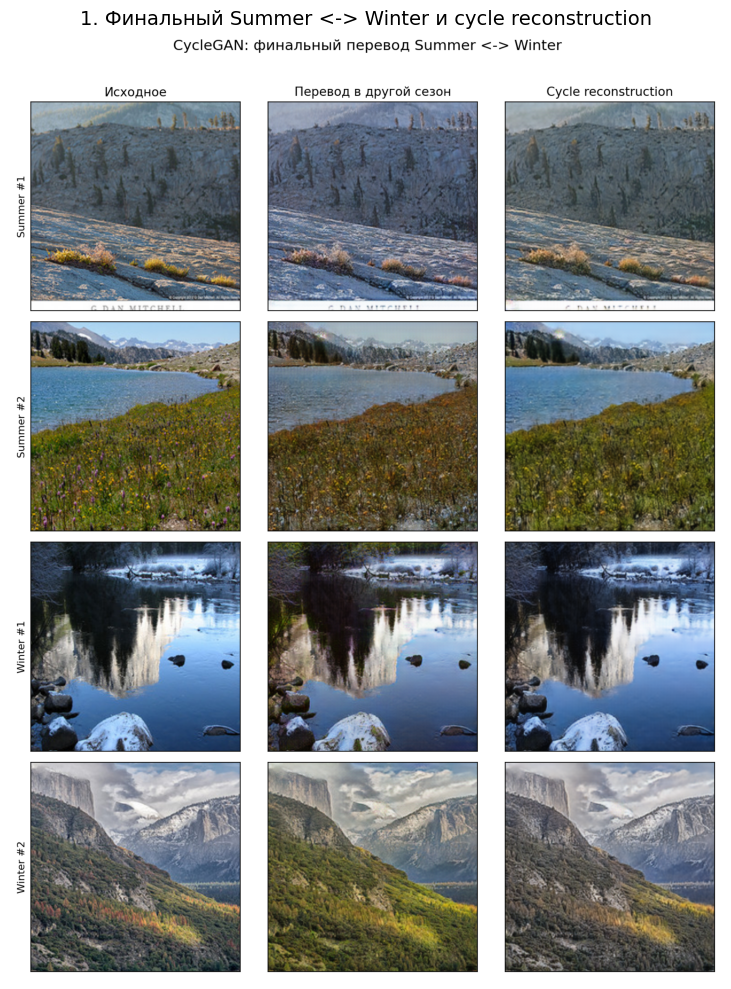

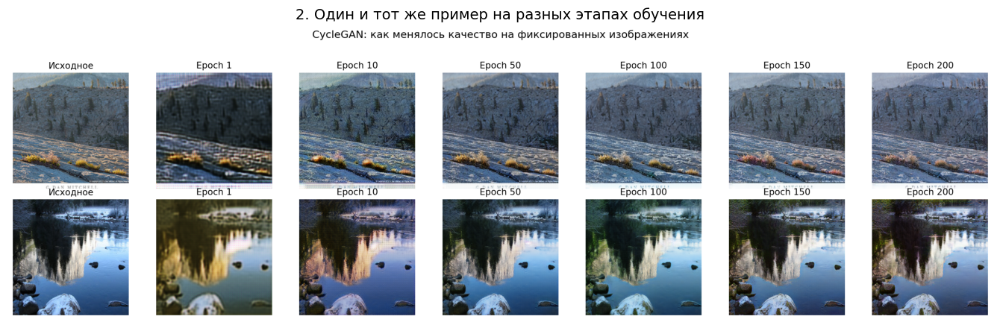

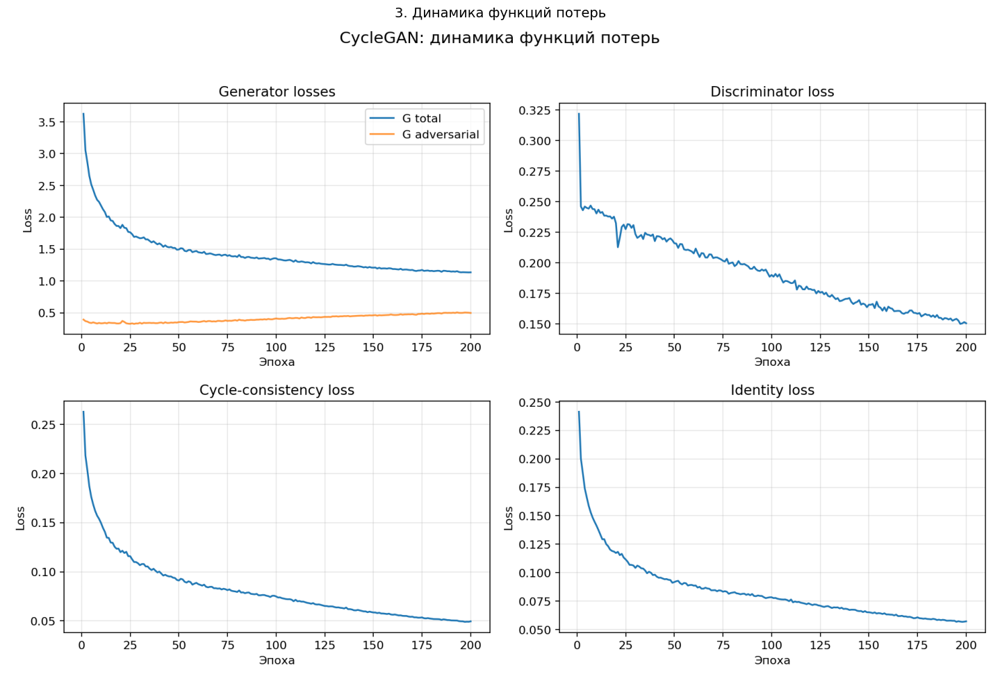

Показано 3 итоговых графика(ов) CycleGAN.


In [20]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

result_dir = Path('cyclegan_results')
summary_files = [
    (result_dir / 'final_gallery.png', '1. Финальный Summer <-> Winter и cycle reconstruction'),
    (result_dir / 'progression.png', '2. Один и тот же пример на разных этапах обучения'),
    (result_dir / 'losses.png', '3. Динамика функций потерь'),
]

existing = [(path, title) for path, title in summary_files if path.exists()]

if not existing:
    print('Итоговых файлов пока нет.')
else:
    for path, title in existing:
        image = mpimg.imread(path)
        # Размер подбирается по пропорциям изображения, чтобы вывод не был
        # ни слишком высоким, ни слишком мелким.
        h, w = image.shape[:2]
        width = 15
        height = min(10, max(4.5, width * h / w))
        plt.figure(figsize=(width, height))
        plt.imshow(image)
        plt.title(title, fontsize=14)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

    print(f'Показано {len(existing)} итоговых графика(ов) CycleGAN.')


## Обратная связь
- [ ] Почта: d83073452@yandex.ru
- [ ] Gmail: 3073452@gmail.com
- [ ] Telegram: @sleepingzzzZ